# Optimization

**Table of contents**<a id='toc0_'></a>    
- 1. [The consumer problem](#toc1_)    
- 2. [Setup](#toc2_)    
- 3. [The true solution](#toc3_)    
- 4. [Grid search](#toc4_)    
  - 4.1. [Searching the whole budget set](#toc4_1_)    
  - 4.2. [Using monotonicity](#toc4_2_)    
- 5. [Writing an optimizer: gradient descent](#toc5_)    
  - 5.1. [The algorithm](#toc5_1_)    
  - 5.2. [Passing parameters to the objective](#toc5_2_)    
  - 5.3. [Running it](#toc5_3_)    
  - 5.4. [The step size](#toc5_4_)    
  - 5.5. [Choosing the tolerance](#toc5_5_)    
- 6. [Calling a solver: scipy.optimize](#toc6_)    
  - 6.1. [One variable: minimize_scalar](#toc6_1_)    
  - 6.2. [Constrained: SLSQP](#toc6_2_)    
  - 6.3. [Unconstrained: BFGS and Nelder-Mead](#toc6_3_)    
  - 6.4. [The settings you can choose](#toc6_4_)    
  - 6.5. [Pros and cons](#toc6_5_)    
- 7. [Comparing all the methods](#toc7_)    
- 8. [Multi-start: when there is more than one hill](#toc8_)    
- 9. [Summary](#toc9_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

**The plan.** We solve *one* small problem - a consumer choosing between two goods - in *many* different ways, and compare:

1. We solve the problem **by hand** first. Not because you can usually do that - you cannot, or you would not be here - but because having one case with a known answer makes it much easier to see what the numerical methods are doing.
2. **Grid search:** try a lot of points and keep the best. Slow, but impossible to get wrong.
3. **Gradient descent:** we write our own optimizer, just like `bisection` in the next lecture. This is where you see what an optimizer actually *does*, and where the step size and the tolerance come from.
4. **`scipy.optimize`:** the solvers you will use in practice - and how to choose between them.

**The one thing to take away:** an optimizer is not magic. It is a loop that stops when it stops making progress, and it can stop in the wrong place.

## 1. <a id='toc1_'></a>[The consumer problem](#toc0_)

A consumer buys two goods, $x_1$ and $x_2$, with **Cobb-Douglas** preferences

$$ u(x_1,x_2) = x_1^{\alpha}x_2^{1-\alpha}, \qquad 0 < \alpha < 1 $$

and cannot spend more than the income $I$,

$$ p_1x_1 + p_2x_2 \leq I, \qquad x_1 \geq 0,\; x_2 \geq 0 $$

So the problem is

$$ \max_{x_1,x_2\ \geq\ 0}\; x_1^{\alpha}x_2^{1-\alpha} \qquad \text{s.t.} \qquad p_1x_1+p_2x_2 \leq I $$

**Two features we will use again and again:**

* **The budget constraint binds.** Utility is increasing in both goods, so the consumer always spends everything: $p_1x_1+p_2x_2 = I$. This is what we call **monotonicity** below, and it lets us replace $x_2$ by

$$ x_2(x_1) = \frac{I-p_1x_1}{p_2} $$

  turning a problem in *two* variables into a problem in *one*.
* **Maximizing is minimizing.** Every solver in `scipy.optimize` **minimizes**. To maximize $u$ we minimize $-u$. We will call $-u$ the **objective**.

## 2. <a id='toc2_'></a>[Setup](#toc0_)

We import what we need. The grid search algorithms live in **`grid_solve.py`** - the `%autoreload` lines make sure that edits to `.py` files are picked up automatically (**always include these**).

In [1]:
%load_ext autoreload
%autoreload 2

from types import SimpleNamespace
from functools import partial
import time

from scipy import optimize
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'-'})
plt.rcParams.update({'font.size':14})

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

from grid_solve import find_best_choice, find_best_choice_monotone

**The utility function.** Note the `np.maximum`: a negative quantity is not allowed, and $x^{0.5}$ is not even defined for $x<0$. Instead of crashing we say that utility is zero there. Optimizers *will* try such points, so the objective has to survive them.

**Why zero is a safe choice here:** Cobb-Douglas utility is never negative, $u \geq 0$. Setting $u=0$ outside the domain therefore makes those points the **worst** possible, so no optimizer is ever *attracted* to them.

**But it does not work for every utility function.** With $u = \ln x_1 + \ln x_2$, which is very negative for small quantities, returning 0 would make the forbidden region look *better* than the true optimum, and the solver would head straight for it. There you would return `-np.inf` or a large negative number instead. Whatever you return, make sure it is worse than anything the solver can find legitimately.

In [2]:
def u_func(x1,x2,alpha=0.50):
    """ Cobb-Douglas utility, u = x1**alpha * x2**(1-alpha)

    Negative quantities are not possible, so utility is set to zero there.

    Args:

        x1 (float or ndarray): consumption of good 1
        x2 (float or ndarray): consumption of good 2
        alpha (float): weight on good 1

    Returns:

        (float or ndarray): utility

    """

    x1 = np.maximum(x1,0.0)
    x2 = np.maximum(x2,0.0)

    return x1**alpha*x2**(1-alpha)

**The parameters.** Try changing them later and re-run the notebook - everything below is written in terms of these.

In [3]:
alpha = 0.50 # weight on good 1
p1 = 1.0 # price of good 1
p2 = 2.0 # price of good 2
I = 10.0 # income

x1_max = I/p1 # most affordable of good 1
x2_max = I/p2 # most affordable of good 2

print(f'alpha = {alpha}, p1 = {p1}, p2 = {p2}, I = {I}')
print(f'the consumer can at most buy x1 = {x1_max} or x2 = {x2_max}')

alpha = 0.5, p1 = 1.0, p2 = 2.0, I = 10.0
the consumer can at most buy x1 = 10.0 or x2 = 5.0


## 3. <a id='toc3_'></a>[The true solution](#toc0_)

This particular problem can be solved with pen and paper. That is a **luxury**: if we could always do that, we would not need any of the machinery below. But when you *do* have a case with a known answer, it is worth using - it is the easiest way to see what the numerical methods are really doing, and to catch it when one of them quietly goes wrong.

Set up the Lagrangian, $\mathcal{L} = x_1^{\alpha}x_2^{1-\alpha} + \lambda(I-p_1x_1-p_2x_2)$, with first-order conditions

$$ \alpha x_1^{\alpha-1}x_2^{1-\alpha} = \lambda p_1, \qquad (1-\alpha)x_1^{\alpha}x_2^{-\alpha} = \lambda p_2 $$

Dividing the two removes $\lambda$ and gives *the marginal rate of substitution equals the price ratio*,

$$ \frac{\alpha x_2}{(1-\alpha)x_1} = \frac{p_1}{p_2} $$

Combined with the binding budget constraint this gives the well-known Cobb-Douglas solution

$$ x_1^{\ast} = \alpha\frac{I}{p_1}, \qquad x_2^{\ast} = (1-\alpha)\frac{I}{p_2} $$

The consumer spends the share $\alpha$ of the income on good 1 and the rest on good 2 - whatever the prices are.

In [4]:
x1_true = alpha*I/p1
x2_true = (1-alpha)*I/p2
u_true = u_func(x1_true,x2_true,alpha)

print(f'x1* = {x1_true:.6f}')
print(f'x2* = {x2_true:.6f}')
print(f'u*  = {u_true:.6f}')

x1* = 5.000000
x2* = 2.500000
u*  = 3.535534


**A helper for the rest of the lecture.** Every method below is run through `report`, which holds it up against the hand-solved answer and stores it, so we can put everything in one table at the end.

Three things are worth reporting:

* the **error** in the choice, $\max(|x_1-x_1^{\ast}|,|x_2-x_2^{\ast}|)$
* the **left-over income**, $I-p_1x_1-p_2x_2$ - it should be zero. A *negative* number means the solution is not affordable!
* the number of **function evaluations**, i.e. how many times the method had to compute $u$. This is the real cost: in a serious model one evaluation can take minutes.

In [5]:
results = {} # all solutions are collected here, keyed by the name of the method

def report(name,x1,x2,nfev=np.nan,do_print=True):
    """ compare a candidate solution with the true solution and store it

    Args:

        name (str): name of the method
        x1 (float): candidate consumption of good 1
        x2 (float): candidate consumption of good 2
        nfev (int): number of function evaluations used
        do_print (bool): print the comparison

    """

    # a. evaluate the candidate
    u = u_func(x1,x2,alpha)
    error = max(np.abs(x1-x1_true),np.abs(x2-x2_true))
    left_over = I-p1*x1-p2*x2

    # b. store it (a dict keeps the order, and re-running a cell just overwrites)
    results[name] = {'x1':x1,'x2':x2,'u':u,'error':error,'left_over':left_over,'nfev':nfev}

    # c. print it
    if do_print:
        print(f'{name}')
        print(f'  x1 = {x1:.6f} (true: {x1_true:.6f})')
        print(f'  x2 = {x2:.6f} (true: {x2_true:.6f})')
        print(f'  u  = {u:.6f} (true: {u_true:.6f})')
        print(f'  largest error in x   = {error:.2e}')
        print(f'  left-over income     = {left_over:+.2e}')
        if not np.isnan(nfev):
            print(f'  function evaluations = {nfev:,.0f}')

## 4. <a id='toc4_'></a>[Grid search](#toc0_)

### 4.1. <a id='toc4_1_'></a>[Searching the whole budget set](#toc0_)

**The idea.** Lay a grid over everything the consumer can afford, compute utility in every point, and keep the best one. Nothing clever happens - and that is the point. If the grid is fine enough this *cannot* fail.

The grids run from nothing to everything of each good,

$$ X_1 = \left\{0,\frac{1}{N_1-1}\frac{I}{p_1},\dots,\frac{I}{p_1}\right\}, \qquad
   X_2 = \left\{0,\frac{1}{N_2-1}\frac{I}{p_2},\dots,\frac{I}{p_2}\right\} $$

and we solve

$$ \max_{x_1\in X_1,\,x_2\in X_2} u(x_1,x_2) \qquad \text{s.t.} \qquad p_1x_1+p_2x_2\leq I $$

The algorithm is `find_best_choice` in `grid_solve.py` - **open it and read it**, it is a double loop and an `if`-statement.

In [6]:
N1,N2 = 500,400

t0 = time.time()
grid = find_best_choice(u_func,alpha,I,p1,p2,N1,N2,do_print=False)
t_grid = time.time()-t0

print(f'the grid has {N1}x{N2} = {N1*N2:,} points and took {t_grid:.2f} seconds\n')
report('grid search (2D)',grid.x1_best,grid.x2_best,nfev=N1*N2)

the grid has 500x400 = 200,000 points and took 1.61 seconds

grid search (2D)
  x1 = 5.010020 (true: 5.000000)
  x2 = 2.493734 (true: 2.500000)
  u  = 3.534637 (true: 3.535534)
  largest error in x   = 1.00e-02
  left-over income     = +2.51e-03
  function evaluations = 200,000


**Look at the left-over income.** The grid search leaves money on the table: no grid point lies exactly on the budget line, so the best *feasible* grid point is strictly inside the budget set. Refining the grid helps, but $N_1\times N_2$ evaluations for two goods becomes $N^{10}$ for ten goods. This is the **curse of dimensionality**.

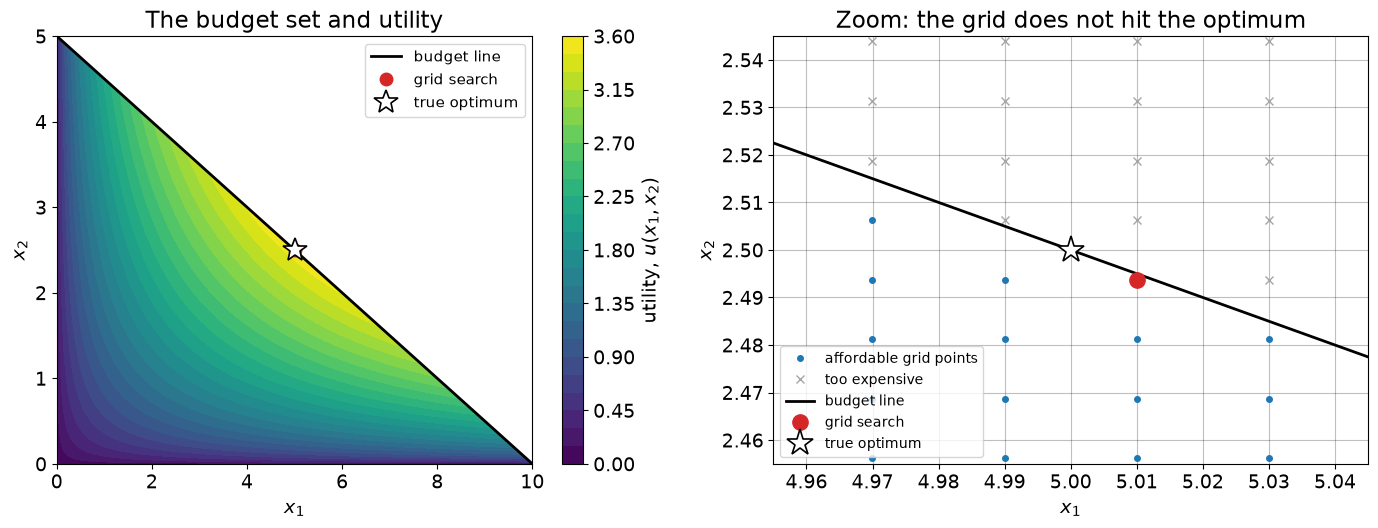

In [7]:
# a. only keep the points the consumer can afford
infeasible = (p1*grid.x1_values + p2*grid.x2_values) > I
u_plot = np.where(infeasible,np.nan,grid.u_values)

# b. the budget line
x1_line = np.linspace(0,x1_max,200)
x2_line = (I-p1*x1_line)/p2

fig = plt.figure(figsize=(14,5.5))

# c. the whole budget set
ax = fig.add_subplot(1,2,1)

cs = ax.contourf(grid.x1_values,grid.x2_values,u_plot,levels=30)
fig.colorbar(cs,ax=ax,label='utility, $u(x_1,x_2)$')

ax.plot(x1_line,x2_line,lw=2,color='black',label='budget line')
ax.plot(grid.x1_best,grid.x2_best,'o',ms=9,color=colors[3],label='grid search')
ax.plot(x1_true,x2_true,'*',ms=18,color='white',mec='black',mew=1.2,label='true optimum')

ax.set_title('The budget set and utility')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(0,x1_max)
ax.set_ylim(0,x2_max)
ax.legend(loc='upper right',fontsize=11)
ax.grid(visible=False)

# d. zoom in: at this scale the two solutions are not the same point
ax = fig.add_subplot(1,2,2)

w = 0.045 # half the width of the zoom window
near = (np.abs(grid.x1_values-x1_true) < w) & (np.abs(grid.x2_values-x2_true) < w)
feasible = (p1*grid.x1_values + p2*grid.x2_values) <= I

ax.plot(grid.x1_values[near & feasible],grid.x2_values[near & feasible],'.',ms=8,
        color=colors[0],label='affordable grid points')
ax.plot(grid.x1_values[near & ~feasible],grid.x2_values[near & ~feasible],'x',ms=6,
        color='0.65',label='too expensive')
ax.plot(x1_line,x2_line,lw=2,color='black',label='budget line')
ax.plot(grid.x1_best,grid.x2_best,'o',ms=11,color=colors[3],label='grid search')
ax.plot(x1_true,x2_true,'*',ms=20,color='white',mec='black',mew=1.2,label='true optimum')

ax.set_title('Zoom: the grid does not hit the optimum')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(x1_true-w,x1_true+w)
ax.set_ylim(x2_true-w,x2_true+w)
ax.legend(loc='lower left',fontsize=10)

fig.tight_layout()

### 4.2. <a id='toc4_2_'></a>[Using monotonicity](#toc0_)

**More utility is always better**, so the consumer never throws money away: the optimum is *on* the budget line, not inside it. That is one line of economics, and it removes an entire dimension:

$$ \max_{x_1\in X_1}\; u\!\left(x_1,\frac{I-p_1x_1}{p_2}\right) $$

Now a grid over $x_1$ alone is enough, and every point tried is exactly on the budget line. The algorithm is `find_best_choice_monotone`.

In [8]:
N = 500

t0 = time.time()
mono = find_best_choice_monotone(u_func,alpha,I,p1,p2,N,do_print=False)
t_mono = time.time()-t0

print(f'the grid has {N} points and took {t_mono:.4f} seconds\n')
report('grid search (monotone)',mono.x1_best,mono.x2_best,nfev=N)

the grid has 500 points and took 0.0032 seconds

grid search (monotone)
  x1 = 5.010020 (true: 5.000000)
  x2 = 2.494990 (true: 2.500000)
  u  = 3.535527 (true: 3.535534)
  largest error in x   = 1.00e-02
  left-over income     = +0.00e+00
  function evaluations = 500


**400 times fewer evaluations, and a better answer.** The left-over income is now zero to machine precision, because every point on the grid lies exactly on the budget line.

*Knowing something about your problem beats brute force.* Keep that in mind for the rest of the lecture.

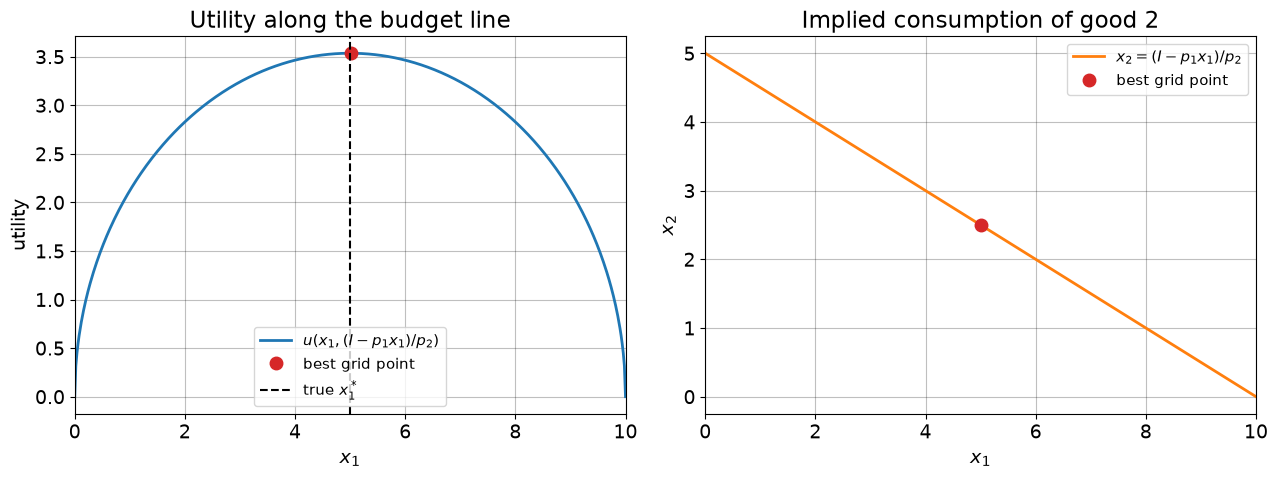

In [9]:
fig = plt.figure(figsize=(13,5))

# a. the objective along the budget line
ax = fig.add_subplot(1,2,1)
ax.plot(mono.x1_values,mono.u_values,lw=2,color=colors[0],label='$u(x_1,(I-p_1x_1)/p_2)$')
ax.plot(mono.x1_best,mono.u_best,'o',ms=9,color=colors[3],label='best grid point')
ax.axvline(x1_true,ls='--',lw=1.5,color='black',label='true $x_1^*$')

ax.set_title('Utility along the budget line')
ax.set_xlabel('$x_1$')
ax.set_ylabel('utility')
ax.set_xlim(0,x1_max)
ax.legend(loc='lower center',fontsize=11)

# b. the implied x2
ax = fig.add_subplot(1,2,2)
ax.plot(mono.x1_values,mono.x2_values,lw=2,color=colors[1],label='$x_2 = (I-p_1x_1)/p_2$')
ax.plot(mono.x1_best,mono.x2_best,'o',ms=9,color=colors[3],label='best grid point')

ax.set_title('Implied consumption of good 2')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(0,x1_max)
ax.legend(loc='upper right',fontsize=11)

fig.tight_layout()

**Task:** Try $N = 50$, $500$, $5000$ and $50000$ in the cell above. How fast does the error fall when you add points?

In [10]:
# write your code here

In [11]:
# answer
for N_now in [50,500,5000,50000]:
    sol = find_best_choice_monotone(u_func,alpha,I,p1,p2,N_now,do_print=False)
    error = np.abs(sol.x1_best-x1_true)
    print(f'N = {N_now:6d}: x1 = {sol.x1_best:.6f}, error = {error:.2e}')

N =     50: x1 = 4.897959, error = 1.02e-01
N =    500: x1 = 5.010020, error = 1.00e-02
N =   5000: x1 = 5.001000, error = 1.00e-03


N =  50000: x1 = 4.999900, error = 1.00e-04


Ten times more points gives ten times smaller error. That is a **terrible** rate: every extra digit costs ten times more work. The optimizers below do far better.

**And a warning about luck.** Try $N=51$ instead of $50$: the error is *exactly* zero. With 51 points the grid runs $0, 0.2, 0.4, \dots$ and happens to contain $x_1=5$ exactly. That is not accuracy, that is a coincidence - and it disappears the moment you change a price. Never judge a method from a single lucky grid.

## 5. <a id='toc5_'></a>[Writing an optimizer: gradient descent](#toc0_)

### 5.1. <a id='toc5_1_'></a>[The algorithm](#toc0_)

A grid search *looks everywhere*. A real optimizer *follows the slope*: it looks at the ground under its feet and steps downhill. That is **gradient descent**.

**First, the convention.** Optimizers **minimize** - every single one in `scipy.optimize`, and ours too. We want to *maximize* utility, so from here on we work with the **objective**

$$ f(x_1) = -u\big(x_1,x_2(x_1)\big) $$

Minimizing $-u$ is the same as maximizing $u$. It is also why the method is called gradient *descent*: we always walk downhill, even though the economics is about getting as high up as possible. Keep the minus sign in mind whenever you read a number off the objective.

We use monotonicity again, so there is only **one** variable to choose, $x_1$, and only one derivative to worry about. The step is

$$ x_{k+1} = x_k - \gamma\,f'(x_k) $$

where $\gamma > 0$ is the **step size**. If the slope is positive we move left, if it is negative we move right, and the steeper it is the further we go.

When do we stop? As for `bisection` in the next lecture, an iterative algorithm needs **two** stopping rules:

* a **tolerance** $\epsilon$: stop when $|f'(x_k)| < \epsilon$ - the ground is flat, we cannot improve
* a **maximum number of iterations**: stop anyway, so a bad run ends instead of hanging

The tolerance says *"we are done"*, the iteration limit says *"this is not working"*. You need both.

**Algorithm:** `gradient_descent()`

1. Choose a starting point $x_0$, a step size $\gamma$, a tolerance $\epsilon$ and a maximum number of iterations.
2. Compute the derivative $f'(x_k)$.
3. If $|f'(x_k)| < \epsilon$: **stop**, we are at a flat point.
4. Otherwise step downhill, $x_{k+1} = x_k - \gamma f'(x_k)$.
5. Go back to step 2 - unless $k$ has reached the maximum, then **stop** and report failure.

We rarely want to differentiate by hand, so we do it **numerically** with a *forward difference*: nudge $x$ a little and see how much $f$ changes,

$$ f'(x) \approx \frac{f(x+h)-f(x)}{h} $$

We are standing in $x$ anyway, so $f(x)$ is already known and the derivative costs **one** extra evaluation.

*(A **central** difference, $(f(x+h)-f(x-h))/2h$, is more accurate but costs two, and cannot re-use $f(x)$. `scipy` also uses forward differences by default.)*

**Choosing $h$** is a balance: too big and the slope is not local, too small and $f(x+h)$ and $f(x)$ round to the same floating-point number so the difference is noise. Around $10^{-6}$ works well here.

In [12]:
def numerical_derivative(f,x,fx,h=1e-6):
    """ the derivative of f in the point x, by a forward difference

    Args:

        f (callable): function taking a float and returning a float
        x (float): the point to differentiate in
        fx (float): the function value in x, which we already know
        h (float): the size of the nudge

    Returns:

        (float): the derivative

    """

    return (f(x+h)-fx)/h

In [13]:
def gradient_descent(f,x0,gamma=0.1,max_iter=1_000,tol=1e-8):
    """ minimize f by stepping against the derivative

    Args:

        f (callable): function to minimize, takes a float and returns a float
        x0 (float): initial guess
        gamma (float): step size
        max_iter (int): maximum number of iterations
        tol (float): stop when the derivative is smaller than this

    Returns:

        x (float): the point where the algorithm stopped
        k (int): number of iterations used
        info (SimpleNamespace): converged, nfev and the full history

    """

    # a. initialize
    x = x0
    x_l,f_l,d_l = [],[],[] # history of points, function values and derivatives
    converged = False
    nfev = 0
    k = 0

    # b. iterate
    while k < max_iter:

        # i. where are we, and which way is downhill?
        fx = f(x)
        dfx = numerical_derivative(f,x,fx)
        nfev += 2 # one for f, one for the derivative

        # ii. remember it
        x_l.append(x)
        f_l.append(fx)
        d_l.append(np.abs(dfx))

        # iii. stop if the ground is flat
        if d_l[-1] < tol:
            converged = True
            break

        # iv. step downhill
        x = x - gamma*dfx
        k += 1

    # c. collect the history
    info = SimpleNamespace(converged=converged,nfev=nfev,
                           x=np.array(x_l),f=np.array(f_l),d=np.array(d_l))

    return x,k,info

### 5.2. <a id='toc5_2_'></a>[Passing parameters to the objective](#toc0_)

The objective depends on $\alpha,I,p_1,p_2$ - but `gradient_descent` wants a function of $x_1$ **only**. This comes up every time you use an optimizer.

In [14]:
def value_of_choice(x1,alpha,I,p1,p2):
    """ minus utility when x2 follows from the budget constraint

    Args:

        x1 (float): consumption of good 1
        alpha (float): weight on good 1
        I (float): income
        p1 (float): price of good 1
        p2 (float): price of good 2

    Returns:

        (float): minus utility

    """

    x2 = (I-p1*x1)/p2 # monotonicity: the budget constraint binds

    return -u_func(x1,x2,alpha)

There are three standard ways to get rid of the parameters:

1. **a `lambda`** - short and readable
2. **`functools.partial`** - *partialling out* the parameters: it returns a new function with some arguments already filled in
3. **`args=...`** - every `scipy` optimizer takes an `args` tuple and passes it on to your function. Nothing to build, but it only works for `scipy`

The first two give exactly the same function:

In [15]:
obj_lambda = lambda x1: value_of_choice(x1,alpha,I,p1,p2)
obj_partial = partial(value_of_choice,alpha=alpha,I=I,p1=p1,p2=p2)

print(f'lambda  : {obj_lambda(3.0):.8f}')
print(f'partial : {obj_partial(3.0):.8f}')

lambda  : -3.24037035
partial : -3.24037035


**A warning about `lambda` in a loop.** A `lambda` looks up its variables when it is *called*, not when it is *created*:

```python
objs = [lambda x1: value_of_choice(x1,alpha,I,p1,p2) for p1 in [1.0,2.0]] # both use the LAST p1!
objs = [partial(value_of_choice,alpha=alpha,I=I,p1=p1,p2=p2) for p1 in [1.0,2.0]] # correct
```

With `partial` the value is frozen when the function is made. If in doubt, use `partial`.

### 5.3. <a id='toc5_3_'></a>[Running it](#toc0_)

Start from $x_1 = 1$, far below the true answer of 5.

In [16]:
obj = partial(value_of_choice,alpha=alpha,I=I,p1=p1,p2=p2)

x1_gd,k,info_gd = gradient_descent(obj,x0=1.0,gamma=0.5,tol=1e-8,max_iter=1_000)

print(f'converged: {info_gd.converged} after {k} iterations\n')
report('gradient descent',x1_gd,(I-p1*x1_gd)/p2,nfev=info_gd.nfev)

converged: True after 241 iterations

gradient descent
  x1 = 4.999999 (true: 5.000000)
  x2 = 2.500000 (true: 2.500000)
  u  = 3.535534 (true: 3.535534)
  largest error in x   = 5.69e-07
  left-over income     = +0.00e+00
  function evaluations = 484


Six digits of accuracy from a few hundred evaluations - against a fourth digit from the 200,000 of the grid search.

The figure shows what happened: long steps where the objective is steep, shorter and shorter as the ground flattens. The algorithm slows down exactly when it gets close.

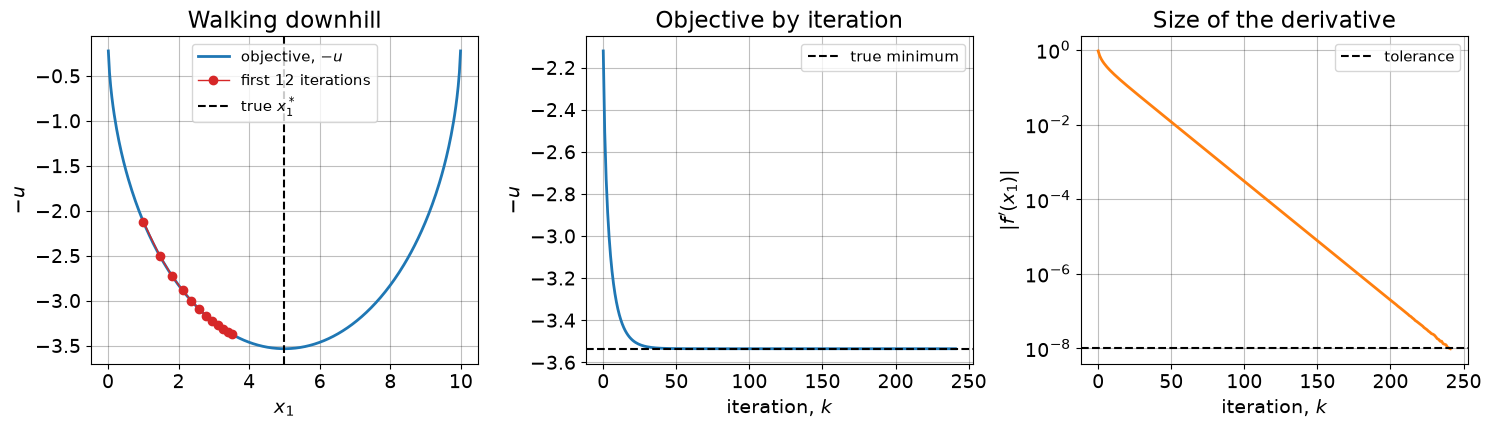

In [17]:
fig = plt.figure(figsize=(15,4.5))

# a. the path down the objective
ax = fig.add_subplot(1,3,1)

x1_grid = np.linspace(0.01,x1_max-0.01,300)
f_grid = np.array([obj(x1_now) for x1_now in x1_grid])

ax.plot(x1_grid,f_grid,lw=2,color=colors[0],label='objective, $-u$')
n_show = 12
ax.plot(info_gd.x[:n_show],info_gd.f[:n_show],'o-',ms=6,lw=1,color=colors[3],
        label=f'first {n_show} iterations')
ax.axvline(x1_true,ls='--',lw=1.5,color='black',label='true $x_1^*$')

ax.set_title('Walking downhill')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$-u$')
ax.legend(loc='upper center',fontsize=11)

# b. the objective by iteration
ax = fig.add_subplot(1,3,2)
ax.plot(info_gd.f,lw=2,color=colors[0])
ax.axhline(-u_true,ls='--',lw=1.5,color='black',label='true minimum')

ax.set_title('Objective by iteration')
ax.set_xlabel('iteration, $k$')
ax.set_ylabel('$-u$')
ax.legend(loc='upper right',fontsize=11)

# c. the size of the derivative by iteration
ax = fig.add_subplot(1,3,3)
ax.plot(info_gd.d,lw=2,color=colors[1])
ax.axhline(1e-8,ls='--',lw=1.5,color='black',label='tolerance')
ax.set_yscale('log')

ax.set_title('Size of the derivative')
ax.set_xlabel('iteration, $k$')
ax.set_ylabel("$|f'(x_1)|$")
ax.legend(loc='upper right',fontsize=11)

fig.tight_layout()

**The middle and the right panel say the same thing very differently.** In the middle the objective looks converged after 50 iterations. On the log scale to the right the derivative keeps falling, straight as a ruler, for another 200. *Always look at convergence on a log scale.*

### 5.4. <a id='toc5_4_'></a>[The step size](#toc0_)

$\gamma$ is ours to choose, and it decides whether the optimizer works at all.

gamma = 0.05:  2489 iterations,  4,980 evaluations, error = 5.71e-07
gamma = 0.50:   241 iterations,    484 evaluations, error = 5.69e-07
gamma = 2.00:    53 iterations,    108 evaluations, error = 5.61e-07
gamma = 5.00:    15 iterations,     32 evaluations, error = 4.75e-07


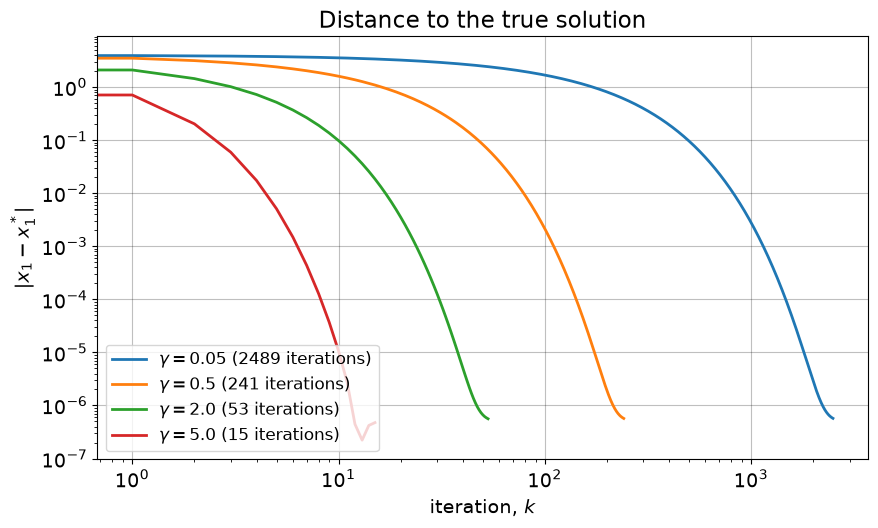

In [18]:
fig = plt.figure(figsize=(9,5.5))
ax = fig.add_subplot(1,1,1)

for gamma in [0.05,0.5,2.0,5.0]:

    x_g,k_g,info_g = gradient_descent(obj,x0=1.0,gamma=gamma,tol=1e-8,max_iter=20_000)
    distance = np.abs(info_g.x-x1_true) # distance to the true solution

    ax.plot(distance,lw=2,label=fr'$\gamma={gamma}$ ({k_g} iterations)')
    print(f'gamma = {gamma:4.2f}: {k_g:5d} iterations, {info_g.nfev:6,d} evaluations, error = {np.abs(x_g-x1_true):.2e}')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Distance to the true solution')
ax.set_xlabel('iteration, $k$')
ax.set_ylabel('$|x_1-x_1^*|$')
ax.legend(loc='lower left',fontsize=12)

fig.tight_layout()

**Bigger steps, fewer iterations** - so why not take enormous ones? Because the derivative only describes the function *close to* where we stand:

In [19]:
x_bad,k_bad,info_bad = gradient_descent(obj,x0=1.0,gamma=10.0,tol=1e-8,max_iter=1_000)

print(f'converged: {info_bad.converged} after {k_bad} iterations')
print(f'x1 = {x_bad:.4f} (true: {x1_true:.4f}), u = {u_func(x_bad,(I-p1*x_bad)/p2,alpha):.4f} (true: {u_true:.4f})')

converged: True after 1 iterations
x1 = 10.4281 (true: 5.0000), u = 0.0000 (true: 3.5355)


**The algorithm says `converged = True` - and the answer is nonsense.**

The first step was so long that it jumped clear out of the budget set, to an $x_1$ above $I/p_1$ where $x_2$ is negative. Utility there is zero - the *worst* value possible, as we made sure in section 2 - but it is also completely **flat**, so the derivative is zero and the stopping rule is satisfied. The algorithm found a flat point, as asked. It just is not a maximum.

**`converged = True` means *"I stopped making progress"*, never *"this is the right answer"*.**

Here the hand-solved answer makes that obvious - but you would not need it. $x_1 = 10.43$ costs more than the entire income, $x_2$ is negative, and we ended at a *lower* utility than we started from. Those are the checks you can always run:

* does the answer satisfy the constraints and make economic sense?
* is it better than the point you started from?
* do different starting points, and different methods, agree?

**Task:** Try $\gamma = 5,6,7,8,9$ from $x_0=1$. Where does it break down - and does the algorithm warn you?

In [20]:
# write your code here

In [21]:
# answer
for gamma in [5.0,6.0,7.0,8.0,9.0]:
    x_g,k_g,info_g = gradient_descent(obj,x0=1.0,gamma=gamma,max_iter=20_000)
    print(f'gamma = {gamma:4.1f}: x1 = {x_g:8.4f}, {k_g:5d} iterations, converged = {info_g.converged}')

gamma =  5.0: x1 =   5.0000,    15 iterations, converged = True
gamma =  6.0: x1 =   5.0000,    10 iterations, converged = True
gamma =  7.0: x1 =   5.0000,     6 iterations, converged = True
gamma =  8.0: x1 =   5.0000,    11 iterations, converged = True
gamma =  9.0: x1 =  -3.4330,     2 iterations, converged = True


### 5.5. <a id='toc5_5_'></a>[Choosing the tolerance](#toc0_)

The tolerance is the other knob, and the temptation is to make it as small as possible. Let us see what that buys.

In [22]:
print(f'{"tolerance":>11s}{"iterations":>12s}{"error in x1":>14s}')
for tol in [1e-2,1e-3,1e-4,1e-6,1e-8,1e-10,1e-12]:
    x_t,k_t,info_t = gradient_descent(obj,x0=1.0,gamma=0.5,tol=tol,max_iter=100_000)
    print(f'{tol:>11.0e}{k_t:>12d}{np.abs(x_t-x1_true):>14.2e}')

  tolerance  iterations   error in x1
      1e-02          53      6.68e-02
      1e-03          84      6.88e-03
      1e-04         116      6.59e-04
      1e-06         178      7.48e-06
      1e-08         241      5.69e-07
      1e-10         281      5.03e-07
      1e-12         281      5.03e-07


Down to about $10^{-6}$ the error follows the tolerance one-for-one. Below that it **stops improving**: asking for $10^{-12}$ costs 40 more iterations and buys nothing at all.

**Why?** Our derivative is not exact. A forward difference has an error of order $h$, so with $h=10^{-6}$ the derivative is only good to about $10^{-7}$. Once the tolerance is below the noise in the derivative, we are asking the algorithm to chase numbers it cannot compute.

**Rule of thumb: never ask for a tolerance smaller than the accuracy of what you are measuring.**

**And there is a second, sneakier reason** to be modest about precision: near an optimum the objective is **flat**. Moving $x_1$ away from the optimum barely changes utility.

In [23]:
f_star = obj(x1_true)
for dx in [1e-1,1e-2,1e-3,1e-4]:
    print(f'x1 wrong by {dx:.0e}  ->  objective changes by {obj(x1_true+dx)-f_star:.1e}')

x1 wrong by 1e-01  ->  objective changes by 7.1e-04
x1 wrong by 1e-02  ->  objective changes by 7.1e-06
x1 wrong by 1e-03  ->  objective changes by 7.1e-08
x1 wrong by 1e-04  ->  objective changes by 7.1e-10


Look at the pattern: **ten times closer in $x_1$, a hundred times smaller change in $f$**. That is what "flat at the top" means, and it cuts both ways:

* a tight tolerance **on the objective** is easy to satisfy and says very little about $x$
* the computer knows $f$ to about 16 digits, so $x$ can never be pinned down to better than about **8** digits by comparing function values - half the digits, always

This is why the methods differ in *what* they put the tolerance on. Our `gradient_descent` stops on the derivative; `scipy` lets you stop on the derivative (`gtol`), on the change in the objective (`ftol`), or on the change in $x$ (`xatol`). If you care about a parameter value, put the tolerance on $x$ - not on $f$.

**In practice:** $10^{-6}$ to $10^{-8}$ is a sensible default. If a solver will not converge, the answer is usually a *looser* tolerance or a better-scaled problem - not a tighter tolerance.

## 6. <a id='toc6_'></a>[Calling a solver: scipy.optimize](#toc0_)

Our gradient descent was written to be *understood*, not to be fast. Real solvers estimate the curvature to choose the step length, do line searches, and handle constraints properly. You should never write your own for real work - but you should know what is inside, which is why we wrote one.

**Documentation:** [scipy.optimize](https://docs.scipy.org/doc/scipy/reference/optimize.html) and the [tutorial](https://docs.scipy.org/doc/scipy/tutorial/optimize.html).

All solvers return a **result object** with the same fields:

| field | meaning |
| --- | --- |
| `res.x` | the solution |
| `res.fun` | the objective in the solution |
| `res.success` | did it stop because it was happy? |
| `res.message` | why it stopped, in words |
| `res.nit` | iterations used |
| `res.nfev` | function evaluations used |

### 6.1. <a id='toc6_1_'></a>[One variable: minimize_scalar](#toc0_)

With monotonicity we have a problem in **one** variable, and `optimize.minimize_scalar` is the right tool. Two methods matter:

* **`brent`** fits a parabola through three points and jumps to its minimum, with a safer fallback when that misbehaves. It searches the whole real line.
* **`bounded`** does the same *inside a `bounds` interval you give it*, and never leaves it.

It takes the same objective as our own optimizer - a function of one number - and we use the third way of passing parameters, `args=`.

In [24]:
# a. brent: searches everywhere
res_brent = optimize.minimize_scalar(value_of_choice,
    method='brent',args=(alpha,I,p1,p2))

report('scipy: minimize_scalar (brent)',res_brent.x,(I-p1*res_brent.x)/p2,nfev=res_brent.nfev)
print('')

# b. bounded: never leaves [0,I/p1]
res_bounded = optimize.minimize_scalar(value_of_choice,
    method='bounded',bounds=(0,x1_max),args=(alpha,I,p1,p2))

report('scipy: minimize_scalar (bounded)',res_bounded.x,(I-p1*res_bounded.x)/p2,nfev=res_bounded.nfev)

scipy: minimize_scalar (brent)
  x1 = 5.000000 (true: 5.000000)
  x2 = 2.500000 (true: 2.500000)
  u  = 3.535534 (true: 3.535534)
  largest error in x   = 8.84e-11
  left-over income     = +0.00e+00
  function evaluations = 15

scipy: minimize_scalar (bounded)
  x1 = 5.000000 (true: 5.000000)
  x2 = 2.500000 (true: 2.500000)
  u  = 3.535534 (true: 3.535534)
  largest error in x   = 8.88e-16
  left-over income     = +0.00e+00
  function evaluations = 6


**Six function evaluations** for machine precision. The grid search needed 200,000 for four digits.

Use `bounded` whenever you know where the answer must be - which in economics is almost always ($x_1$ cannot be negative or exceed $I/p_1$). It cannot wander off into the flat region where our objective is meaningless.

### 6.2. <a id='toc6_2_'></a>[Constrained: SLSQP](#toc0_)

Now suppose we do *not* substitute the budget constraint away. Then we need a solver that understands constraints - and it matters *which kind*:

* a **bound** is a box around each variable on its own, $a_i \le x_i \le b_i$
* a **constraint** can be any shape, $g(x)\ge0$ or $h(x)=0$, and may tie several variables together

Our budget $p_1x_1+p_2x_2\le I$ is a real constraint, not a bound. **`SLSQP`** takes both kinds, so it goes straight in as $I-p_1x_1-p_2x_2 \geq 0$. A bounds-only method such as `L-BFGS-B` (the `B` is for *bounds*) could not take it.

**Note the signature.** `minimize` hands your function an **array**, where `minimize_scalar` handed it a number. This is a classic source of confusion.

In [25]:
# a. the objective in two variables - no constraint inside, the solver handles it
def value_of_choice_2d(x,alpha,I,p1,p2):
    return -u_func(x[0],x[1],alpha)

# b. the budget constraint: this function must be >= 0
constraints = ({'type':'ineq','fun': lambda x: I-p1*x[0]-p2*x[1]},)

# c. bounds on each variable separately
bounds = ((1e-8,x1_max),(1e-8,x2_max))

# d. where to start
x0 = np.array([2.0,1.0])

res_slsqp = optimize.minimize(value_of_choice_2d,x0,args=(alpha,I,p1,p2),
    method='SLSQP',bounds=bounds,constraints=constraints,options={'ftol':1e-12})

print(res_slsqp.message)
print('')
report('scipy: SLSQP (constrained)',res_slsqp.x[0],res_slsqp.x[1],nfev=res_slsqp.nfev)

Optimization terminated successfully

scipy: SLSQP (constrained)
  x1 = 5.000000 (true: 5.000000)
  x2 = 2.500000 (true: 2.500000)
  u  = 3.535534 (true: 3.535534)
  largest error in x   = 3.70e-07
  left-over income     = -1.87e-13
  function evaluations = 24


**This is the method to reach for** when your problem has real constraints. Seven digits in 24 evaluations, and the left-over income is zero: SLSQP knows the constraint exactly.

*(For many variables with only simple bounds, `L-BFGS-B` is the usual workhorse - see the table in section 6.5.)*

### 6.3. <a id='toc6_3_'></a>[Unconstrained: BFGS and Nelder-Mead](#toc0_)

What if the solver knows nothing about constraints at all? Left alone it would buy an infinite amount of both goods, so we have to handle the budget **ourselves**. Two devices:

1. **A projection.** If the proposed bundle is too expensive, scale it back onto the budget line before computing utility,

$$ (x_1,x_2) \;\longrightarrow\; \frac{I}{p_1x_1+p_2x_2}\,(x_1,x_2) $$

  Both goods are cut by the same factor, so we always evaluate a bundle the consumer can actually afford. **This is what makes the answer exactly feasible.**

2. **A penalty.** On top of that, a cost $\mu\cdot(p_1x_1+p_2x_2-I)$ of *asking* for something unaffordable, so the solver is pushed back inside instead of drifting off.

In [26]:
def budget_projection(x1,x2,I,p1,p2):
    """ scale a bundle back onto the budget line if it is not affordable """

    E = p1*x1 + p2*x2 # what the bundle costs

    if E > I: # too expensive: cut both goods by the same factor
        x1 *= I/E
        x2 *= I/E

    return x1,x2

In [27]:
def value_of_choice_penalty(x,alpha,I,p1,p2,mu=0.10):
    """ minus utility, with the budget handled by projection and penalty

    Args:

        x (ndarray): array of length 2 with the proposed consumption
        alpha (float): weight on good 1
        I (float): income
        p1 (float): price of good 1
        p2 (float): price of good 2
        mu (float): weight on the penalty

    Returns:

        (float): minus utility of the affordable bundle, plus the penalty

    """

    x1,x2 = x[0],x[1]

    # a. how much too expensive was the proposal?
    excess = np.maximum(p1*x1 + p2*x2 - I,0.0)

    # b. move it onto the budget line
    x1,x2 = budget_projection(x1,x2,I,p1,p2)

    # c. utility of what can be bought, minus the cost of asking for too much
    return -u_func(x1,x2,alpha) + mu*excess

**Careful when you read off the answer.** The solver returns the *proposal*, not the bundle it was scored on. What the consumer buys is the **projected** bundle, so that is what we report.

Now two very different solvers on this objective:

* **`BFGS`** uses the derivative - like our gradient descent, but it also learns the curvature and takes much better steps. It assumes the function is **smooth**.
* **`Nelder-Mead`** uses no derivatives at all. It keeps a triangle of points (a *simplex*) and reflects the worst corner through the others.

In [28]:
# BFGS: uses the gradient (computed numerically, since we do not supply jac)
res_bfgs = optimize.minimize(value_of_choice_penalty,x0,args=(alpha,I,p1,p2,0.10),method='BFGS')

x1_now,x2_now = budget_projection(res_bfgs.x[0],res_bfgs.x[1],I,p1,p2)

print(f'success: {res_bfgs.success} - {res_bfgs.message}')
report('scipy: BFGS (projection)',x1_now,x2_now,nfev=res_bfgs.nfev)

success: False - Desired error not necessarily achieved due to precision loss.
scipy: BFGS (projection)
  x1 = 3.390440 (true: 5.000000)
  x2 = 3.304780 (true: 2.500000)
  u  = 3.347336 (true: 3.535534)
  largest error in x   = 1.61e+00
  left-over income     = +3.79e-09
  function evaluations = 222


In [29]:
# Nelder-Mead: no derivatives at all
res_nm = optimize.minimize(value_of_choice_penalty,x0,args=(alpha,I,p1,p2,0.10),method='Nelder-Mead')

x1_now,x2_now = budget_projection(res_nm.x[0],res_nm.x[1],I,p1,p2)

print(f'success: {res_nm.success} - {res_nm.message}')
report('scipy: Nelder-Mead (projection)',x1_now,x2_now,nfev=res_nm.nfev)

success: True - Optimization terminated successfully.
scipy: Nelder-Mead (projection)
  x1 = 5.000089 (true: 5.000000)
  x2 = 2.499955 (true: 2.500000)
  u  = 3.535534 (true: 3.535534)
  largest error in x   = 8.94e-05
  left-over income     = +2.02e-09
  function evaluations = 123


**BFGS gives up.** `success = False`, and *"Desired error not necessarily achieved due to precision loss"* is what a gradient-based method says when the derivatives stop making sense.

**Why?** The projection puts a **corner** in the objective. Walking outwards from inside the budget set, utility rises - until the budget line, where the projection kicks in and it stops rising completely. The slope jumps at that point, and BFGS is built on the assumption that it does not.

**Nelder-Mead walks straight to the answer** in about 120 evaluations, five digits, exactly on the budget line. It is slow on smooth problems, but it never differentiates anything, so the corner does not bother it.

**Could we rescue BFGS with smaller steps?** No - and that is worth understanding. Unlike our own gradient descent, **BFGS has no step size for us to set**: it picks its own step lengths with a *line search*, and a line search works by assuming the function is smooth enough to interpolate. That assumption is exactly what the corner breaks.

The knobs we *do* have are the tolerance and the step used for its numerical gradient. Let us try them - and, as a last resort, simply hand the solver the right answer as its starting point.

In [30]:
settings = [('default',x0,{}),
            ('looser tolerance (gtol=1e-2)',x0,{'gtol':1e-2}),
            ('bigger gradient step (eps=1e-4)',x0,{'eps':1e-4}),
            ('started AT the true optimum',np.array([x1_true,x2_true]),{})]

print(f'{"BFGS setting":<34s}{"error":>10s}{"evals":>8s}{"success":>10s}')
for label,x0_now,options in settings:

    res = optimize.minimize(value_of_choice_penalty,x0_now,args=(alpha,I,p1,p2,0.10),
        method='BFGS',options=options)

    x1_now,x2_now = budget_projection(res.x[0],res.x[1],I,p1,p2)
    error = max(np.abs(x1_now-x1_true),np.abs(x2_now-x2_true))

    print(f'{label:<34s}{error:>10.1e}{res.nfev:>8d}{str(res.success):>10s}')

BFGS setting                           error   evals   success
default                              1.6e+00     222     False
looser tolerance (gtol=1e-2)         1.6e+00     222     False
bigger gradient step (eps=1e-4)      1.6e+00     174     False
started AT the true optimum          0.0e+00     132     False


**Nothing helps.** The tolerance changes nothing at all - BFGS is not stopping because the gradient got small, it is aborting because its line search failed.

And look at the last row. Started **at the exact answer**, it returns the exact answer - and *still* reports `success = False`. It cannot even certify a solution it was handed, because at a corner the numerical derivative never looks like zero.

**Match the method to the shape of your objective.** Smooth and differentiable: use the derivative. Corners, kinks, `if`-statements, simulation noise: go derivative-free. This is not a knob you can tune your way out of.

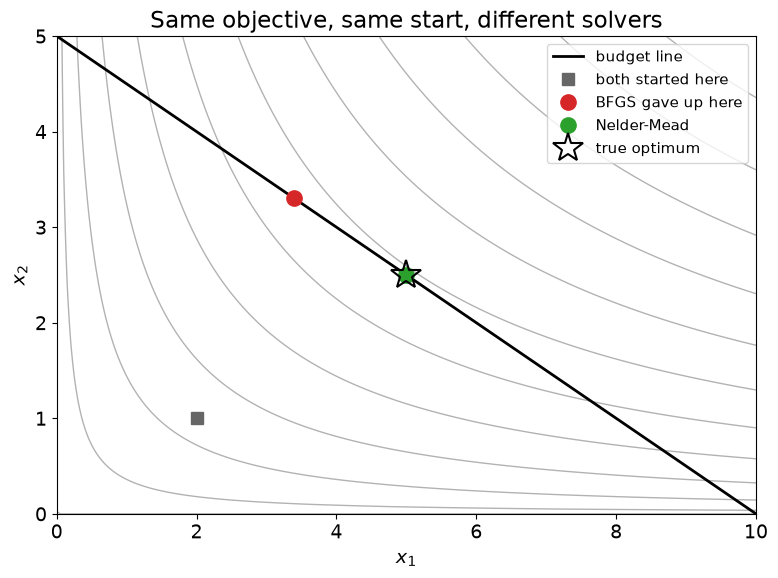

In [31]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1,1)

x1_vec = np.linspace(0,x1_max,200)
x2_vec = np.linspace(0,x2_max,200)
x1_mesh,x2_mesh = np.meshgrid(x1_vec,x2_vec,indexing='ij')
u_mesh = u_func(x1_mesh,x2_mesh,alpha)

ax.contour(x1_mesh,x2_mesh,u_mesh,levels=12,linewidths=1,colors='black',alpha=0.30)
ax.plot(x1_line,x2_line,lw=2,color='black',label='budget line')

ax.plot(x0[0],x0[1],'s',ms=9,color='0.4',label='both started here')
ax.plot(*budget_projection(res_bfgs.x[0],res_bfgs.x[1],I,p1,p2),'o',ms=11,color=colors[3],label='BFGS gave up here')
ax.plot(*budget_projection(res_nm.x[0],res_nm.x[1],I,p1,p2),'o',ms=11,color=colors[2],label='Nelder-Mead')
ax.plot(x1_true,x2_true,'*',ms=22,mfc='none',mec='black',mew=1.5,label='true optimum')

ax.set_title('Same objective, same start, different solvers')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_xlim(0,x1_max)
ax.set_ylim(0,x2_max)
ax.legend(loc='upper right',fontsize=11)
ax.grid(visible=False)

fig.tight_layout()

**And what about $\mu$?** With the projection it hardly matters, because asking for more than you can afford already buys nothing. Any positive $\mu$ will do:

In [32]:
print(f'{"mu":>8s}{"x1":>12s}{"x2":>12s}{"left-over":>13s}{"evaluations":>14s}')
for mu in [0.1,1.0,10.0,100.0]:
    res = optimize.minimize(value_of_choice_penalty,x0,args=(alpha,I,p1,p2,mu),method='Nelder-Mead')
    x1_now,x2_now = budget_projection(res.x[0],res.x[1],I,p1,p2)
    print(f'{mu:>8.1f}{x1_now:>12.6f}{x2_now:>12.6f}{I-p1*x1_now-p2*x2_now:>13.1e}{res.nfev:>14d}')

      mu          x1          x2    left-over   evaluations
     0.1    5.000089    2.499955      2.0e-09           123
     1.0    4.999967    2.500016      6.4e-11           123
    10.0    4.999982    2.500009      6.8e-09           130
   100.0    4.999915    2.500043      3.5e-09           145


Without the projection - a bare penalty $\mu\cdot\max(0,p_1x_1+p_2x_2-I)^2$ - the answer would sit slightly *outside* the budget set, and you would have to push $\mu$ up to shrink the violation, which makes the objective steeper and harder to optimize. With the projection there is nothing to trade off.

### 6.4. <a id='toc6_4_'></a>[The settings you can choose](#toc0_)

Every solver takes the same handful of arguments. These are the ones worth knowing:

| argument | who takes it | what it does |
| --- | --- | --- |
| `x0` | all of `minimize` | the starting guess - the most important choice you make |
| `args` | all | extra parameters, passed straight on to your function |
| `bounds` | `bounded`, `L-BFGS-B`, `SLSQP` | a box for each variable, $a_i\le x_i\le b_i$ |
| `constraints` | `SLSQP` | general $g(x)\ge0$ or $h(x)=0$ |
| `jac` | the gradient-based ones | your own gradient. Without it, `scipy` computes one numerically - as we did |
| `tol` | all | one number for "how precise", the easy way in |
| `options` | all | a dictionary of method-specific settings, see below |

and inside `options`:

| option | who | what it does |
| --- | --- | --- |
| `maxiter` | all | maximum number of iterations - your safety net |
| `disp` | all | print what the solver is doing |
| `gtol` | `BFGS`, `L-BFGS-B` | stop when the gradient is this small |
| `ftol` | `SLSQP`, `L-BFGS-B` | stop when the objective stops changing this much |
| `xatol`, `fatol` | `Nelder-Mead` | stop when $x$ or $f$ stops changing this much |

Notice that these are the same two ideas as in our own `gradient_descent`: **a tolerance** and **a maximum number of iterations**. Every solver in the library has them, under one name or another.

`disp=True` is the fastest way to find out what a solver is actually doing:

In [33]:
res = optimize.minimize(value_of_choice_2d,x0,args=(alpha,I,p1,p2),
    method='SLSQP',bounds=bounds,constraints=constraints,
    options={'ftol':1e-12,'maxiter':100,'disp':True})

Optimization terminated successfully    (Exit mode 0)
            Current function value: -3.535533905932794
            Iterations: 8
            Function evaluations: 24
            Gradient evaluations: 8


**And the starting point matters.** All of these methods walk downhill from where you put them:

In [34]:
print(f'{"start":>18s}{"x1":>12s}{"x2":>12s}{"iterations":>13s}{"evaluations":>14s}')
for x0_now in [[0.1,0.1],[2.0,1.0],[4.9,2.4],[9.9,0.01]]:
    res = optimize.minimize(value_of_choice_2d,np.array(x0_now),args=(alpha,I,p1,p2),
        method='SLSQP',bounds=bounds,constraints=constraints,options={'ftol':1e-12})
    print(f'{str(x0_now):>18s}{res.x[0]:>12.6f}{res.x[1]:>12.6f}{res.nit:>13d}{res.nfev:>14d}')

             start          x1          x2   iterations   evaluations
        [0.1, 0.1]    5.000000    2.500000            8            24
        [2.0, 1.0]    5.000000    2.500000            8            24
        [4.9, 2.4]    5.000000    2.500000            5            15
       [9.9, 0.01]    5.000000    2.500000            7            22


Here every start finds the same answer, because our problem is nicely curved and has a single peak. **Do not count on that** - section 8 shows what happens when it is not true.

### 6.5. <a id='toc6_5_'></a>[Pros and cons](#toc0_)

| method | what it does | pros | cons | use it when |
| --- | --- | --- | --- | --- |
| **grid search** | tries everything | cannot fail, trivial to write, finds *global* optimum | hopeless in more than 2-3 variables, low accuracy | you need a first look, or a starting point |
| **gradient descent** (ours) | one step downhill at a time | simple to understand | slow, and you must tune $\gamma$ yourself | never in practice - but know how it works |
| **`brent`** | fits parabolas, 1 variable | fast, no derivatives, no starting point | one variable only, unbounded | 1 variable, well-behaved |
| **`bounded`** | `brent` inside an interval | fast, and stays where it belongs | one variable only, needs bounds | 1 variable and you know the range |
| **`SLSQP`** | constrained, uses gradients | handles *real* constraints and bounds; exactly feasible | needs a smooth objective and a starting point | you have constraints |
| **`L-BFGS-B`** | quasi-Newton with bounds | very fast; made for many variables; low memory | bounds only, no general constraints | estimating a model with many parameters |
| **`BFGS`** | quasi-Newton, no constraints | fast and accurate on smooth problems | no constraints; **gives up on kinks** | unconstrained and smooth |
| **`Nelder-Mead`** | crawls with a simplex | no derivatives; survives kinks, penalties and noise | slow; no constraints; struggles in many variables | your objective is not smooth |

**A rule of thumb.** Reduce the problem with what you know (monotonicity!), put it in as few variables as possible, give the solver real bounds and real constraints rather than penalties, and start it somewhere sensible. Then almost anything works.

## 7. <a id='toc7_'></a>[Comparing all the methods](#toc0_)

Everything we ran was passed through `report`, so we can now put it in one table. The interesting columns are the last two: **how wrong** is the answer, and **how much did it cost**.

In [35]:
print(f'{"method":<34s}{"x1":>9s}{"x2":>9s}{"u":>11s}{"error":>11s}{"left-over":>12s}{"evals":>10s}')
print('-'*96)
for name,res in results.items():
    print(f'{name:<34s}{res["x1"]:>9.4f}{res["x2"]:>9.4f}{res["u"]:>11.6f}'
          f'{res["error"]:>11.1e}{res["left_over"]:>12.1e}{res["nfev"]:>10,.0f}')

method                                   x1       x2          u      error   left-over     evals
------------------------------------------------------------------------------------------------
grid search (2D)                     5.0100   2.4937   3.534637    1.0e-02     2.5e-03   200,000
grid search (monotone)               5.0100   2.4950   3.535527    1.0e-02     0.0e+00       500
gradient descent                     5.0000   2.5000   3.535534    5.7e-07     0.0e+00       484
scipy: minimize_scalar (brent)       5.0000   2.5000   3.535534    8.8e-11     0.0e+00        15
scipy: minimize_scalar (bounded)     5.0000   2.5000   3.535534    8.9e-16     0.0e+00         6
scipy: SLSQP (constrained)           5.0000   2.5000   3.535534    3.7e-07    -1.9e-13        24
scipy: BFGS (projection)             3.3904   3.3048   3.347336    1.6e+00     3.8e-09       222
scipy: Nelder-Mead (projection)      5.0001   2.5000   3.535534    8.9e-05     2.0e-09       123


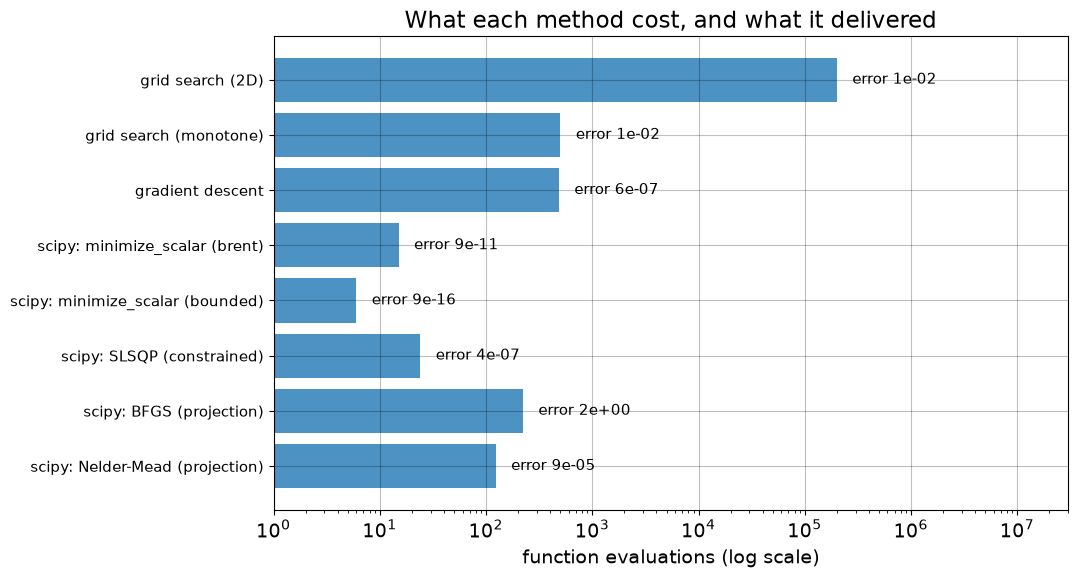

In [36]:
fig = plt.figure(figsize=(11,6))
ax = fig.add_subplot(1,1,1)

names = list(results.keys())
nfevs = [res['nfev'] for res in results.values()]
errors = [max(res['error'],1e-16) for res in results.values()]

y = np.arange(len(names))
ax.barh(y,nfevs,color=colors[0],alpha=0.80)

for i,(n,e) in enumerate(zip(nfevs,errors)):
    ax.text(n*1.4,i,f'error {e:.0e}',va='center',fontsize=11)

ax.set_yticks(y)
ax.set_yticklabels(names,fontsize=11)
ax.invert_yaxis()
ax.set_xscale('log')
ax.set_xlim(1,max(nfevs)*150)
ax.set_title('What each method cost, and what it delivered')
ax.set_xlabel('function evaluations (log scale)')

fig.tight_layout()

**Read the figure from the bottom up.** Six evaluations at the cheap end, two hundred thousand at the expensive end - and the cheap methods are the *accurate* ones. Nothing was bought with all those evaluations except our unwillingness to think about the problem first.

And note the two entries where a lot of work bought nothing at all: the 2D grid search, which is both the most expensive and among the least accurate, and BFGS, which spent 222 evaluations to end up 1.6 units away because the objective had a corner in it.

## 8. <a id='toc8_'></a>[Multi-start: when there is more than one hill](#toc0_)

Every method above found the same answer, from every starting point. That is because the consumer problem has **one peak**: utility rises towards the optimum and falls away from it, seen from anywhere in the budget set.

**Most models are not that kind.** Fixed costs, discrete choices, several regimes, or an objective built by matching moments to data - any of these can give you an objective with several local minima. A solver then does exactly what it promised: it walks downhill from where you put it and stops in the nearest valley. *Which* valley is decided by your starting guess, not by the solver.

Here is a small objective with three local minima:

In [37]:
def wiggly(x):
    """ an objective with more than one local minimum """

    return 0.15*(x[0]-4)**2 + np.cos(2*x[0])

In [38]:
for x0 in [2.0,5.0,8.0]:
    res = optimize.minimize(wiggly,np.array([x0]),method='BFGS')
    print(f'start at x = {x0:.1f}  ->  x = {res.x[0]:.4f}, f = {res.fun:+.4f}, success = {res.success}')

start at x = 2.0  ->  x = 1.7434, f = -0.1772, success = True
start at x = 5.0  ->  x = 4.6626, f = -0.9292, success = True
start at x = 8.0  ->  x = 7.5713, f = +1.0687, success = True


**Three starting points, three different answers - and all three report `success = True`.**

The solver is not lying to us. Each run really did find a point where the ground is flat and the neighbours are worse. That is all a local optimizer ever promises. Only one of the three is the answer we were looking for.

**The fix is embarrassingly simple: start from many points and keep the best.**

In [39]:
# a. many starting points
starts = np.linspace(0.5,9.5,25)

# b. solve from each of them
solutions = np.empty(starts.size)
values = np.empty(starts.size)
nfev = 0

for i,x0 in enumerate(starts):

    res = optimize.minimize(wiggly,np.array([x0]),method='BFGS')

    solutions[i] = res.x[0]
    values[i] = res.fun
    nfev += res.nfev

# c. keep the best one
best = np.argmin(values)

print(f'best of {starts.size} starts: x = {solutions[best]:.6f}, f = {values[best]:+.6f}')
print(f'total cost: {nfev} function evaluations')
print('')

# d. how many different answers did we get?
for x_now in np.unique(np.round(solutions,3)):
    n_now = np.sum(np.abs(solutions-x_now) < 1e-2)
    print(f'  x = {x_now:6.3f} found {n_now:2d} times, f = {wiggly([x_now]):+.4f}')

best of 25 starts: x = 4.662611, f = -0.929190
total cost: 322 function evaluations

  x =  1.743 found  8 times, f = -0.1772
  x =  4.663 found 10 times, f = -0.9292
  x =  7.571 found  7 times, f = +1.0687


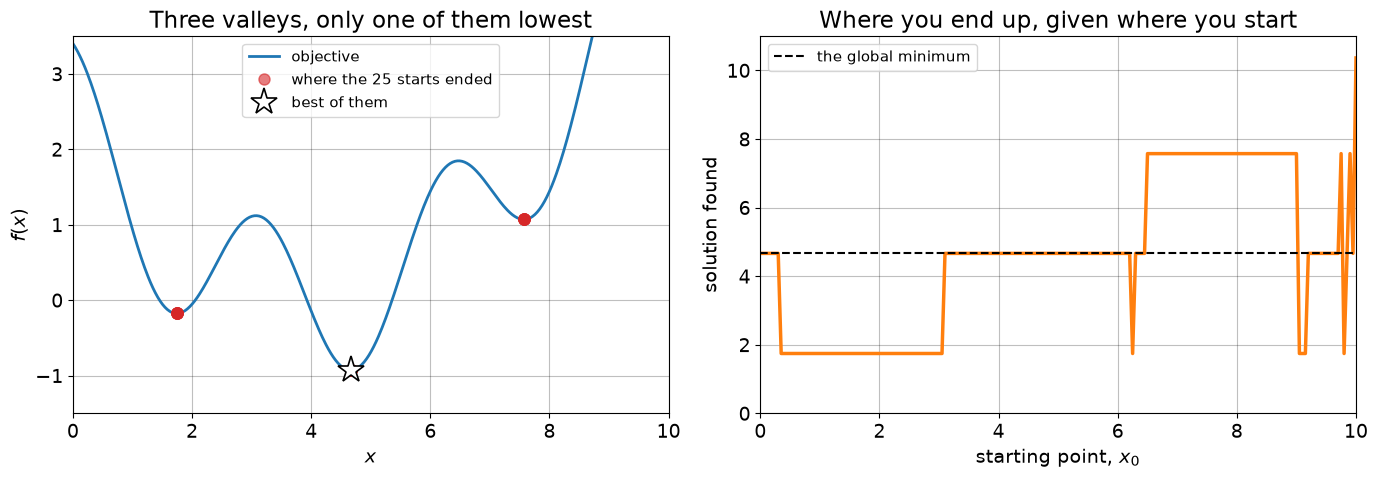

In [40]:
# a. the function and the basins
x_grid = np.linspace(0,10,500)
f_grid = np.array([wiggly([x_now]) for x_now in x_grid])

x_starts = np.linspace(0,10,201)
x_ends = np.array([optimize.minimize(wiggly,np.array([x0]),method='BFGS').x[0] for x0 in x_starts])

fig = plt.figure(figsize=(14,5))

# b. the objective, with everything the multi-start found
ax = fig.add_subplot(1,2,1)
ax.plot(x_grid,f_grid,lw=2,color=colors[0],label='objective')
ax.plot(solutions,values,'o',ms=8,color=colors[3],alpha=0.60,label='where the 25 starts ended')
ax.plot(solutions[best],values[best],'*',ms=20,color='white',mec='black',mew=1.2,label='best of them')

ax.set_title('Three valleys, only one of them lowest')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_xlim(0,10)
ax.set_ylim(-1.5,3.5)
ax.legend(loc='upper center',fontsize=11)

# c. where does each starting point end up?
ax = fig.add_subplot(1,2,2)
ax.plot(x_starts,x_ends,lw=2.5,color=colors[1])
ax.axhline(solutions[best],ls='--',lw=1.5,color='black',label='the global minimum')

ax.set_title('Where you end up, given where you start')
ax.set_xlabel('starting point, $x_0$')
ax.set_ylabel('solution found')
ax.set_xlim(0,10)
ax.set_ylim(0,11)
ax.legend(loc='upper left',fontsize=11)

fig.tight_layout()

**The right panel is the whole lesson in one picture.** It is mostly a staircase: starting points on the same step all end in the same valley. Each step is a **basin of attraction**, and only one of them leads to the right answer. Land outside it and you get a wrong answer delivered with `success = True`.

Notice the ragged bit on the far right. There the solver takes a long first step, sails over a hill and lands somewhere else entirely - so nearby starting points can end in completely different valleys. Basins are not always tidy intervals, which is one more reason not to trust a single start.

**And it is cheap.** Twenty-five starts cost a few hundred function evaluations - less than our own gradient descent needed on a problem with a single peak.

**In practice:**

* spread the starting points over the region where the answer could plausibly be - a grid, or random draws (with a seed, so you can reproduce them)
* if all the starts agree, you have some evidence that there is only one optimum. It is evidence, not proof
* if they disagree, keep the best one - and say so, rather than quietly reporting the first answer you got

## 9. <a id='toc9_'></a>[Summary](#toc0_)

1. **Always have something to check against.** A hand-solved case is the nicest, and you will rarely have one. Failing that: do the constraints hold, is the answer better than where you started, and do different methods and starting points agree?
2. **An optimizer is a loop with two stopping rules:** a **tolerance** (we are done) and a **maximum number of iterations** (this is not working). Everything in `scipy.optimize` has both.
3. **`converged = True` is not a proof.** It means the algorithm stopped improving. It can be flat, stuck, or outside the region where your model makes sense - as in section 5.4.
4. **Use what you know about the problem.** Monotonicity turned two variables into one, removed the constraint, removed the penalty weight, and made everything faster *and* more accurate.
5. **Handle constraints in the right order:** substitute them away if you can; otherwise give them to a solver that takes them (`SLSQP`); and only then reach for a projection and a penalty.
6. **Match the method to the shape of the objective.** A projection guarantees a feasible answer but puts a corner in it - and gradient-based methods such as `BFGS` break on corners, while derivative-free `Nelder-Mead` does not blink.
7. **Passing parameters:** `args=(...)` for `scipy`, `partial(f,...)` or a `lambda` for everything else. Prefer `partial` inside loops.
8. **Watch out for the signatures:** `minimize_scalar` gives your function a number, `minimize` gives it an array. And a solver returns the *proposal* - if your objective transforms it, report the transformed bundle.
9. **Plot convergence on a log scale** - on a linear scale everything looks converged long before it is.
10. **Always use several starting points.** A solver only ever finds the valley you dropped it into. `success = True` from one start tells you nothing about whether it is the *best* valley - and multi-start costs almost nothing.

Questions? **Socrative room:** PROGECON